# Fine-Tune YOLOS-Tiny for PPE (Hard Hat) Detection

This notebook fine-tunes [**YOLOS-Tiny**](https://huggingface.co/hustvl/yolos-tiny) (You Only Look at One Sequence) on a hard hat / PPE detection dataset.

**Why YOLOS-Tiny?**
- Only **6 million parameters** — trains fast on a free T4 GPU
- Fast inference (~30ms per image on GPU)
- Fully compatible with the Hugging Face `object-detection` pipeline — **drop-in replacement** for the DETR models used by the SiteWatch AI backend
- Vision-Transformer-based architecture with competitive accuracy

**Labels (3 classes):**
| ID | Label | Meaning |
|----|--------|----------|
| 0 | `helmet` | Person wearing a hard hat ✅ |
| 1 | `head` | Exposed head, no hard hat ⚠️ |
| 2 | `person` | Person (body) detected |

**Steps:**
1. Install dependencies
2. Upload the dataset (5 000 images + Pascal VOC XMLs)
3. Parse annotations → Hugging Face Dataset
4. Set up image processor & augmentations
5. Fine-tune YOLOS-Tiny (~30 min on T4)
6. Evaluate with visual predictions
7. Push the trained model to Hugging Face Hub
8. Test inference with the `object-detection` pipeline

> ⚡ **Set your Colab runtime to GPU → T4** before running (Runtime → Change runtime type → T4 GPU).

## 1. Install Dependencies

In [1]:
!pip install -q transformers[torch] datasets albumentations timm accelerate
!pip install -q evaluate pycocotools huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [2]:
#check colab runtime 
import torch
print(f"Using device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")


Using device: CPU


In [ ]:
import torch

# Check Colab runtime type (CPU / GPU / TPU)
try:
    import google.colab  # noqa: F401
    print("Environment: Google Colab")
except Exception:
    print("Environment: Not Colab")

runtime_type = "CPU"

if "COLAB_TPU_ADDR" in globals() or "COLAB_TPU_ADDR" in __import__("os").environ:
    runtime_type = "TPU"
else:
    if "torch" not in globals():
        if torch.cuda.is_available():
            runtime_type = f"GPU ({torch.cuda.get_device_name(0)})"

print(f"Runtime type: {runtime_type}")

# Optional: show GPU details when available
if "GPU" in runtime_type:
    !nvidia-smi -L

Environment: Google Colab
Runtime type: CPU


In [26]:
from huggingface_hub import login, whoami
import os
import getpass

# ── Paste your token when prompted (input is hidden) ─────────────────────────
# Get your token at: https://huggingface.co/settings/tokens
# A read/write token is required to push models to the Hub
hf_token = getpass.getpass("Enter your Hugging Face token: ")

if hf_token:
    os.environ["HF_TOKEN"] = hf_token
    login(token=hf_token, add_to_git_credential=False)
    print(f"✅ Logged in as: {whoami()['name']}")
else:
    raise ValueError("No token provided. Get yours at https://huggingface.co/settings/tokens")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Logged in as: ikigaiii


## 2. Upload Dataset

**Google Drive method (recommended for 5 000 images):**

1. Zip your `test_images/` folder locally:
   ```bash
   zip -r hard_hat_dataset.zip test_images/
   ```
2. Upload `hard_hat_dataset.zip` to your Google Drive root
3. Run the cell below to mount Drive and extract

In [ ]:
import os
import shutil
from pathlib import Path

# Navigate to test_images folder and create a zip of the hard_hat_dataset
test_images_path = Path("test_images")

if test_images_path.exists():
    # Create zip file
    shutil.make_archive("hard_hat_dataset", "zip", test_images_path)
    print(f"✅ Created hard_hat_dataset.zip")
    print(f"   File size: {os.path.getsize('hard_hat_dataset.zip') / (1024**2):.2f} MB")
else:
    print(f"❌ test_images folder not found at {test_images_path.absolute()}")

❌ test_images folder not found at /content/test_images


In [16]:
import os
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

# ── Search for the zip anywhere in MyDrive ───────────────────────────────────
drive_root = Path("/content/drive/MyDrive")
matches = sorted(drive_root.rglob("hard_hat_dataset.zip"))

if matches:
    zip_path = str(matches[0])
    print(f"✅ Found zip at: {zip_path}")
else:
    items = sorted(drive_root.iterdir())
    print("❌ hard_hat_dataset.zip not found in Google Drive.")
    print("\nTop-level items in My Drive:")
    for item in items[:20]:
        print(f"  {'📁' if item.is_dir() else '📄'} {item.name}")
    print("\n→ Upload hard_hat_dataset.zip directly instead:")
    from google.colab import files
    uploaded = files.upload()
    zip_name = list(uploaded.keys())[0]
    zip_path = f"/content/{zip_name}"

# ── Extract (-o = overwrite silently, exclude macOS junk files) ───────────────
!cp "{zip_path}" /content/hard_hat_dataset.zip
!unzip -o -q /content/hard_hat_dataset.zip -d /content/ -x "__MACOSX/*" "*.DS_Store"

# ── Detect extracted structure (handles multiple layouts) ─────────────────────
candidates = [
    ("/content/test_images/images",       "/content/test_images/annotations"),
    ("/content/hard_hat_dataset/images",  "/content/hard_hat_dataset/annotations"),
    ("/content/images",                   "/content/annotations"),
]

IMAGES_DIR = ANNOTATIONS_DIR = None
for img_candidate, ann_candidate in candidates:
    if Path(img_candidate).exists() and Path(ann_candidate).exists():
        IMAGES_DIR = img_candidate
        ANNOTATIONS_DIR = ann_candidate
        break

if IMAGES_DIR is None:
    print("Extracted contents of /content:")
    for p in sorted(Path("/content").rglob("*"))[:40]:
        print(f"  {p}")
    raise RuntimeError("Could not locate images/ + annotations/ after extraction. Check paths above.")

print(f"✅ Dataset ready")
print(f"   IMAGES_DIR:      {IMAGES_DIR}")
print(f"   ANNOTATIONS_DIR: {ANNOTATIONS_DIR}")
print(f"   Images:          {len(list(Path(IMAGES_DIR).glob('*')))}")


Mounted at /content/drive
✅ Found zip at: /content/drive/MyDrive/hard_hat_dataset.zip
caution: excluded filename not matched:  __MACOSX/*
✅ Dataset ready
   IMAGES_DIR:      /content/hard_hat_dataset/images
   ANNOTATIONS_DIR: /content/hard_hat_dataset/annotations
   Images:          5000


## 3. Parse Pascal VOC Annotations → HF Dataset

In [17]:
from pathlib import Path
from collections import Counter

import xml.etree.ElementTree as ET

# Fix: define dataset paths if this cell is run before the extraction cell
if "ANNOTATIONS_DIR" not in globals() or "IMAGES_DIR" not in globals():
    candidates = [
        ("/content/test_images/images", "/content/test_images/annotations"),
        ("/content/hard_hat_dataset/images", "/content/hard_hat_dataset/annotations"),
        ("/content/images", "/content/annotations"),
    ]

    IMAGES_DIR = ANNOTATIONS_DIR = None
    for img_dir, ann_dir in candidates:
        if Path(img_dir).exists() and Path(ann_dir).exists():
            IMAGES_DIR, ANNOTATIONS_DIR = img_dir, ann_dir
            break

    if ANNOTATIONS_DIR is None:
        raise RuntimeError(
            "ANNOTATIONS_DIR is not defined and no valid annotations folder was found. "
            "Run the dataset extraction cell first."
        )

print(f"Using ANNOTATIONS_DIR: {ANNOTATIONS_DIR}")

# Discover all labels from the annotation XMLs
label_counter = Counter()
annotation_files = sorted(Path(ANNOTATIONS_DIR).glob("*.xml"))

for xml_path in annotation_files:
    tree = ET.parse(xml_path)
    for obj in tree.findall(".//object/name"):
        label_counter[obj.text] += 1

print(f"Found {len(annotation_files)} annotation files")
print("\nLabel distribution:")
for label, count in label_counter.most_common():
    print(f"  {label}: {count}")

# Build mappings — fixed order for reproducibility
LABELS = sorted(label_counter.keys())
LABEL2ID = {label: idx for idx, label in enumerate(LABELS)}
ID2LABEL = {idx: label for idx, label in enumerate(LABELS)}

print(f"\nLABEL2ID: {LABEL2ID}")
print(f"ID2LABEL: {ID2LABEL}")
print(f"num_labels: {len(LABELS)}")

Using ANNOTATIONS_DIR: /content/hard_hat_dataset/annotations
Found 5000 annotation files

Label distribution:
  helmet: 18966
  head: 5785
  person: 751

LABEL2ID: {'head': 0, 'helmet': 1, 'person': 2}
ID2LABEL: {0: 'head', 1: 'helmet', 2: 'person'}
num_labels: 3


In [18]:
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

# Discover all labels from the annotation XMLs
label_counter = Counter()
annotation_files = sorted(Path(ANNOTATIONS_DIR).glob("*.xml"))

for xml_path in annotation_files:
    tree = ET.parse(xml_path)
    for obj in tree.findall(".//object/name"):
        label_counter[obj.text] += 1

print(f"Found {len(annotation_files)} annotation files")
print(f"\nLabel distribution:")
for label, count in label_counter.most_common():
    print(f"  {label}: {count}")

# Build mappings — fixed order for reproducibility
LABELS = sorted(label_counter.keys())  # ['head', 'helmet', 'person']
LABEL2ID = {label: idx for idx, label in enumerate(LABELS)}
ID2LABEL = {idx: label for idx, label in enumerate(LABELS)}

print(f"\nLABEL2ID: {LABEL2ID}")
print(f"ID2LABEL: {ID2LABEL}")
print(f"num_labels: {len(LABELS)}")

Found 5000 annotation files

Label distribution:
  helmet: 18966
  head: 5785
  person: 751

LABEL2ID: {'head': 0, 'helmet': 1, 'person': 2}
ID2LABEL: {0: 'head', 1: 'helmet', 2: 'person'}
num_labels: 3


In [ ]:
# Fine-tune — ~30 min on a T4 GPU for 50 epochs
train_result = trainer.train()

# Print final metrics
print(f"\nTraining complete!")
print(f"  Final train loss: {train_result.training_loss:.4f}")
metrics = train_result.metrics
for key, value in sorted(metrics.items()):
    print(f"  {key}: {value}")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: WARNING Invalid choice
wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss
1,1.376400,1.239715
2,1.120600,1.014787
3,1.123500,1.001348
4,1.024700,1.020115
5,0.921500,0.957262
6,1.002200,0.931252
7,0.949100,0.947373
8,0.903200,0.935990
9,0.940100,0.916289
10,0.914400,0.916962


In [19]:
def parse_voc_annotations(images_dir: str, annotations_dir: str, label2id: dict) -> list[dict]:
    """Parse all Pascal VOC XML annotations into a list of records
    compatible with Hugging Face object-detection datasets.

    Each record has:
      - image_id: int
      - image: str (path to image file)
      - width, height: int
      - objects: dict with keys id, area, bbox (COCO: [xmin, ymin, w, h]), category
    """
    images_path = Path(images_dir)
    annotations_path = Path(annotations_dir)
    records = []

    xml_files = sorted(annotations_path.glob("*.xml"))

    for image_id, xml_file in enumerate(xml_files):
        tree = ET.parse(xml_file)
        root = tree.getroot()

        filename = root.findtext("filename")
        img_path = str(images_path / filename)

        size = root.find("size")
        width = int(size.findtext("width"))
        height = int(size.findtext("height"))

        obj_ids, areas, bboxes, categories = [], [], [], []
        obj_counter = 0

        for obj in root.findall("object"):
            name = obj.findtext("name")
            if name not in label2id:
                continue

            bndbox = obj.find("bndbox")
            xmin = max(0, int(float(bndbox.findtext("xmin"))))
            ymin = max(0, int(float(bndbox.findtext("ymin"))))
            xmax = min(width, int(float(bndbox.findtext("xmax"))))
            ymax = min(height, int(float(bndbox.findtext("ymax"))))

            w = xmax - xmin
            h = ymax - ymin

            # Skip zero-area boxes
            if w <= 0 or h <= 0:
                continue

            obj_ids.append(obj_counter)
            areas.append(w * h)
            bboxes.append([xmin, ymin, w, h])  # COCO format
            categories.append(label2id[name])
            obj_counter += 1

        records.append({
            "image_id": image_id,
            "image": img_path,
            "width": width,
            "height": height,
            "objects": {
                "id": obj_ids,
                "area": areas,
                "bbox": bboxes,
                "category": categories,
            },
        })

    return records


records = parse_voc_annotations(IMAGES_DIR, ANNOTATIONS_DIR, LABEL2ID)
print(f"Parsed {len(records)} images")
print(f"Example record (first):")
print(f"  image: {records[0]['image']}")
print(f"  objects: {len(records[0]['objects']['id'])} detections")
print(f"  bbox sample: {records[0]['objects']['bbox'][:2]}")
print(f"  categories:  {records[0]['objects']['category'][:2]}")

Parsed 5000 images
Example record (first):
  image: /content/hard_hat_dataset/images/hard_hat_workers0.png
  objects: 13 detections
  bbox sample: [[357, 116, 47, 59], [4, 146, 35, 38]]
  categories:  [1, 1]


In [20]:
from datasets import Dataset, Features, Sequence, Value, Image as DImage

features = Features({
    "image_id": Value("int64"),
    "image": DImage(),
    "width": Value("int64"),
    "height": Value("int64"),
    "objects": {
        "id": Sequence(Value("int64")),
        "area": Sequence(Value("int64")),
        "bbox": Sequence(Sequence(Value("float32"), length=4)),
        "category": Sequence(Value("int64")),
    },
})

dataset = Dataset.from_list(records, features=features)
dataset = dataset.train_test_split(test_size=0.1, seed=42)

print(f"Train: {len(dataset['train'])} images")
print(f"Test:  {len(dataset['test'])} images")
print(f"\nFeatures: {dataset['train'].features}")

Train: 4500 images
Test:  500 images

Features: {'image_id': Value('int64'), 'image': Image(mode=None, decode=True), 'width': Value('int64'), 'height': Value('int64'), 'objects': {'id': List(Value('int64')), 'area': List(Value('int64')), 'bbox': List(List(Value('float32'), length=4)), 'category': List(Value('int64'))}}


## 4. Prepare Image Processor & Transforms

In [21]:
import albumentations as A
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained(
    "hustvl/yolos-tiny",
    size={"shortest_edge": 416, "longest_edge": 416},
    do_resize=True,
    use_fast=True,
)

# Augmentation pipeline for training
train_augment = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
    ],
    bbox_params=A.BboxParams(
        format="coco",  # [xmin, ymin, width, height]
        label_fields=["category"],
        min_area=1,
        min_visibility=0.1,
    ),
)


def _build_annotations(examples, index):
    """Build COCO-style annotations for one example in a batch."""
    image_id = examples["image_id"][index]
    objs = examples["objects"][index]
    return {
        "image_id": image_id,
        "annotations": [
            {
                "image_id": image_id,
                "category_id": objs["category"][j],
                "bbox": objs["bbox"][j],
                "area": objs["area"][j],
                "iscrowd": 0,
            }
            for j in range(len(objs["id"]))
        ],
    }


def format_annotations(examples):
    """Format validation examples (no augmentation)."""
    images = []
    annotations = []

    for i, image in enumerate(examples["image"]):
        if image.mode != "RGB":
            image = image.convert("RGB")
        images.append(image)
        annotations.append(_build_annotations(examples, i))

    result = image_processor(images=images, annotations=annotations, return_tensors="pt")
    # Return a plain dict so datasets can index into it
    return {
        "pixel_values": result["pixel_values"],
        "pixel_mask": result["pixel_mask"],
        "labels": result["labels"],
    }


def format_annotations_with_augmentation(examples):
    """Format training examples with augmentation."""
    images = []
    annotations = []

    for i, image in enumerate(examples["image"]):
        if image.mode != "RGB":
            image = image.convert("RGB")

        image_id = examples["image_id"][i]
        objs = examples["objects"][i]

        augmented = train_augment(
            image=np.array(image),
            bboxes=objs["bbox"],
            category=objs["category"],
        )

        images.append(Image.fromarray(augmented["image"]))
        annotations.append({
            "image_id": image_id,
            "annotations": [
                {
                    "image_id": image_id,
                    "category_id": cat,
                    "bbox": list(bbox),
                    "area": bbox[2] * bbox[3],
                    "iscrowd": 0,
                }
                for bbox, cat in zip(augmented["bboxes"], augmented["category"])
            ],
        })

    result = image_processor(images=images, annotations=annotations, return_tensors="pt")
    return {
        "pixel_values": result["pixel_values"],
        "pixel_mask": result["pixel_mask"],
        "labels": result["labels"],
    }


print("Image processor and augmentation pipeline ready.")


Image processor and augmentation pipeline ready.


In [22]:
# Apply transforms lazily with .with_transform()
train_dataset = dataset["train"].with_transform(format_annotations_with_augmentation)
val_dataset = dataset["test"].with_transform(format_annotations)

# Verify a sample
sample = train_dataset[0]
print("Sample keys:", list(sample.keys()))
print("pixel_values shape:", sample["pixel_values"].shape)
print("labels keys:", list(sample["labels"].keys()))
print("  class_labels:", sample["labels"]["class_labels"])
print("  boxes shape:", sample["labels"]["boxes"].shape)

Sample keys: ['pixel_values', 'pixel_mask', 'labels']
pixel_values shape: torch.Size([3, 400, 416])
labels keys: ['size', 'image_id', 'class_labels', 'boxes', 'area', 'iscrowd', 'orig_size']
  class_labels: tensor([1])
  boxes shape: torch.Size([1, 4])


## 5. Fine-Tune YOLOS-Tiny

In [ ]:
from transformers import AutoModelForObjectDetection

model = AutoModelForObjectDetection.from_pretrained(
    "hustvl/yolos-tiny",
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/26.0M [00:00<?, ?B/s]

Some weights of YolosForObjectDetection were not initialized from the model checkpoint at hustvl/yolos-tiny and are newly initialized because the shapes did not match:
- class_labels_classifier.layers.2.bias: found shape torch.Size([92]) in the checkpoint and torch.Size([4]) in the model instantiated
- class_labels_classifier.layers.2.weight: found shape torch.Size([92, 192]) in the checkpoint and torch.Size([4, 192]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters:     6,471,752
Trainable parameters: 6,471,752


In [23]:
from transformers import TrainingArguments

# Change this to your Hugging Face username/repo
HF_REPO = "ikigaiii/yolos-tiny-ppe-detection"

training_args = TrainingArguments(
    output_dir="yolos-tiny-ppe-finetuned",
    num_train_epochs=50,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,
    weight_decay=1e-4,
    lr_scheduler_type="cosine",
    warmup_steps=200,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=50,
    remove_unused_columns=False,
    push_to_hub=True,
    hub_model_id=HF_REPO,
)

print(f"Training config:")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  LR: {training_args.learning_rate}")
print(f"  FP16: {training_args.fp16}")
print(f"  Hub repo: {HF_REPO}")

Training config:
  Epochs: 50
  Batch size: 16
  LR: 5e-05
  FP16: True
  Hub repo: ikigaiii/yolos-tiny-ppe-detection


In [27]:
import torch
from transformers import Trainer


def collate_fn(batch):
    """Custom collation: stack pixel_values, keep labels as a list of dicts."""
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = [item["labels"] for item in batch]
    return {"pixel_values": pixel_values, "labels": labels}


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=image_processor,
    data_collator=collate_fn,
)

print(f"Trainer ready.")
print(f"  Train samples: {len(train_dataset)}")
print(f"  Val samples:   {len(val_dataset)}")

Trainer ready.
  Train samples: 4500
  Val samples:   500


In [ ]:
from huggingface_hub import whoami, notebook_login

# Confirm you're still authenticated before pushing
try:
    print(f"✅ Authenticated as: {whoami()['name']}")
except Exception:
    notebook_login()


✅ Authenticated as: ikigaiii


In [ ]:
# Fine-tune — ~30 min on a T4 GPU for 50 epochs
train_result = trainer.train()

# Print final metrics
print(f"\nTraining complete!")
print(f"  Final train loss: {train_result.training_loss:.4f}")
metrics = train_result.metrics
for key, value in sorted(metrics.items()):
    print(f"  {key}: {value}")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: WARNING Invalid choice
wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss
1,1.376400,1.239715
2,1.120600,1.014787
3,1.123500,1.001348
4,1.024700,1.020115
5,0.921500,0.957262
6,1.002200,0.931252
7,0.949100,0.947373
8,0.903200,0.935990
9,0.940100,0.916289
10,0.914400,0.916962


In [4]:
from transformers import AutoModelForObjectDetection, AutoImageProcessor

HF_REPO = "ikigaiii/yolos-tiny-ppe-detection"

model = AutoModelForObjectDetection.from_pretrained(HF_REPO)
image_processor = AutoImageProcessor.from_pretrained(HF_REPO)
print("Model loaded successfully")

config.json:   0%|          | 0.00/881 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/25.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

Model loaded successfully


## 6. Evaluate

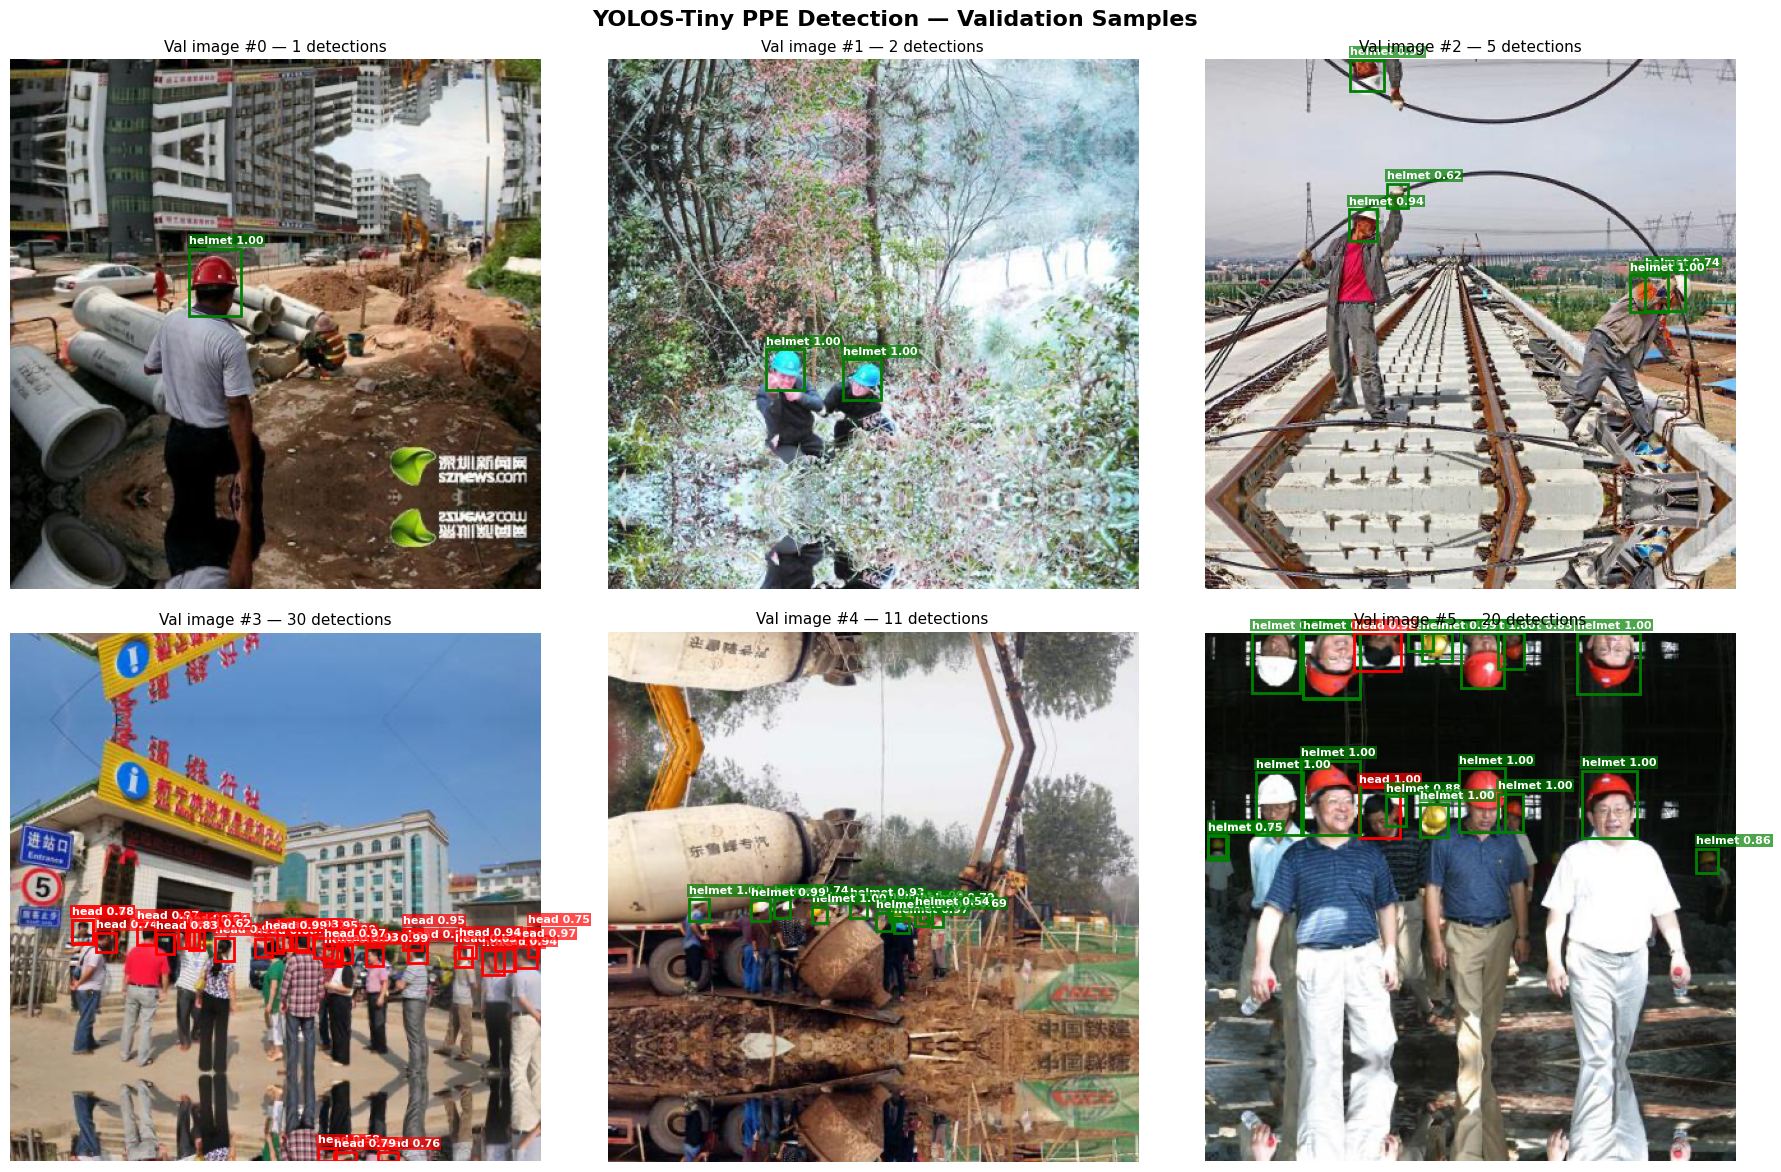

Saved evaluation_results.png


In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from transformers import pipeline

# Set up the detection pipeline with the fine-tuned model
detector = pipeline(
    "object-detection",
    model=trainer.model,
    image_processor=image_processor,
    device=0,
)

# Color map for each label
COLORS = {"helmet": "green", "head": "red", "person": "blue"}
THRESHOLD = 0.5

# Pick 6 images from the validation set
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("YOLOS-Tiny PPE Detection — Validation Samples", fontsize=16, fontweight="bold")

val_indices = [0, 1, 2, 3, 4, 5]

for ax, idx in zip(axes.flatten(), val_indices):
    # Load the raw image from the original dataset (before transforms)
    raw_example = dataset["test"][idx]
    image = raw_example["image"]
    if image.mode != "RGB":
        image = image.convert("RGB")

    # Run inference
    results = detector(image, threshold=THRESHOLD)

    # Display image
    ax.imshow(image)
    ax.set_title(f"Val image #{idx} — {len(results)} detections", fontsize=11)
    ax.axis("off")

    # Draw bounding boxes
    for det in results:
        label = det["label"]
        score = det["score"]
        box = det["box"]  # {xmin, ymin, xmax, ymax}
        color = COLORS.get(label, "yellow")

        x = box["xmin"]
        y = box["ymin"]
        w = box["xmax"] - box["xmin"]
        h = box["ymax"] - box["ymin"]

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x, y - 4,
            f"{label} {score:.2f}",
            fontsize=8, fontweight="bold",
            color="white",
            bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor="none"),
        )

plt.tight_layout()
plt.savefig("evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved evaluation_results.png")

## 7. Push to Hugging Face Hub

In [29]:
# Push the fine-tuned model and image processor to the Hub
trainer.push_to_hub(
    commit_message="Fine-tuned YOLOS-Tiny on PPE hard hat detection dataset",
    tags=["yolos", "object-detection", "ppe", "hard-hat", "safety", "construction"],
)

# Also push the image processor separately (ensures it's bundled)
image_processor.push_to_hub(HF_REPO)

print(f"\n✅ Model pushed to: https://huggingface.co/{HF_REPO}")
print(f"\nNext steps:")
print(f"  1. Deploy as a Hugging Face Inference Endpoint for production use")
print(f"  2. Use with: pipeline('object-detection', model='{HF_REPO}')")
print(f"  3. Update SiteWatch AI backend to use '{HF_REPO}' as the model ID")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...netuned/model.safetensors: 100%|##########| 25.9MB / 25.9MB            

  ...netuned/training_args.bin: 100%|##########| 5.20kB / 5.20kB            

README.md: 0.00B [00:00, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.



✅ Model pushed to: https://huggingface.co/ikigaiii/yolos-tiny-ppe-detection

Next steps:
  1. Deploy as a Hugging Face Inference Endpoint for production use
  2. Use with: pipeline('object-detection', model='ikigaiii/yolos-tiny-ppe-detection')
  3. Update SiteWatch AI backend to use 'ikigaiii/yolos-tiny-ppe-detection' as the model ID


## 8. Test Inference Locally (Optional)

In [30]:
from transformers import pipeline
from PIL import Image

# Load the fine-tuned model from the Hub (or use local path)
detector = pipeline("object-detection", model=HF_REPO, device=0)

# Test on a validation image
test_example = dataset["test"][0]
test_image = test_example["image"]
if test_image.mode != "RGB":
    test_image = test_image.convert("RGB")

results = detector(test_image, threshold=0.3)

print(f"Detected {len(results)} objects:\n")
for det in results:
    label = det["label"]
    score = det["score"]
    box = det["box"]
    print(f"  {label:10s}  confidence={score:.3f}  box=[{box['xmin']}, {box['ymin']}, {box['xmax']}, {box['ymax']}]")

config.json:   0%|          | 0.00/902 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

Detected 1 objects:

  helmet      confidence=1.000  box=[140, 148, 181, 201]
